# Optimization with Simulated Annealing

## Introduction

This notebook documents an optimization module that can be used to optimize player locations in a single tracking frame. The optimization currently only supports the **Simulated Annealing** algorithm, and allows creation of any arbitrary objective or constraint.

The approach is useful for use cases such as:

- Finding defensive repositioning that maximizes xT-weighted pitch control.
- Evaluating trade-offs between pitch control and pressure.
- Measuring how far a team's position is from some theoretical optimal.


```{warning}
Although we try to keep everything up to date, notebook examples can evolve slightly differently from the package internals. If you spot inconsistencies, please open an issue.
```

## Optimization setup

The high-level API is `optimize_tracking_frame()`. You provide:

1. a game and selected frame,
2. objective terms,
3. optional constraints,
4. an optimization algorithm (`SimulatedAnnealing` in this example),
5. algorithm specific hyperparameters like `num_iterations`,`verbose`, `random_state`

In [1]:
import numpy as np
import pandas as pd
import os
from copy import deepcopy
from matplotlib.colors import LinearSegmentedColormap

from databallpy import get_saved_game
from databallpy.features.pitch_control import get_pitch_control_single_frame
from databallpy.optimization.constraints import TTIConstraint
from databallpy.optimization.objectives import (
    PressureObjective,
    WeightedPitchControlObjective,
)
from databallpy.optimization.optimization import optimize_tracking_frame
from databallpy.optimization.simulated_annealing import SimulatedAnnealing
from databallpy.visualize import plot_soccer_pitch, plot_tracking_data

2026-06-29 21:12:49 - databallpy - INFO - Using databallpy version 0.7.3


## Load tracking frame

We'll start by picking one frame from this match, where the Green team LCB is making a pass to the LB.

2026-06-29 21:12:49 - /Users/amar/Documents/databallpy/databallpy/utils/get_game.py - INFO - Trying to run the function `get_saved_game`
2026-06-29 21:12:49 - /Users/amar/Documents/databallpy/databallpy/utils/get_game.py - INFO - Successfully ran the function `get_saved_game`
2026-06-29 21:12:49 - /Users/amar/Documents/databallpy/databallpy/features/differentiate.py - INFO - Trying to run the function `_differentiate`
2026-06-29 21:12:49 - /Users/amar/Documents/databallpy/databallpy/features/differentiate.py - INFO - Successfully ran the function `_differentiate`
2026-06-29 21:12:49 - /Users/amar/Documents/databallpy/databallpy/visualize.py - INFO - Trying to run the function `plot_tracking_data`
2026-06-29 21:12:49 - /Users/amar/Documents/databallpy/databallpy/visualize.py - INFO - Trying to run the function `_pre_check_plot_td_inputs`
2026-06-29 21:12:49 - /Users/amar/Documents/databallpy/databallpy/visualize.py - INFO - Successfully ran the function `_pre_check_plot_td_inputs`
2026-

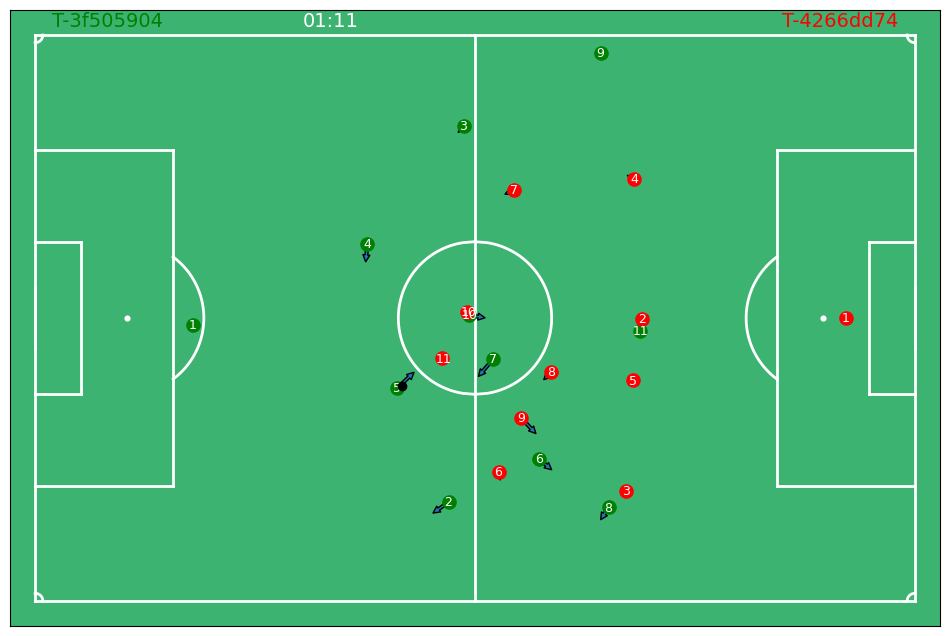

In [2]:
game = get_saved_game("synced_game", os.path.join(os.getcwd(), "../saved_games"))

game.tracking_data.add_velocity(game.get_column_ids() + ["ball"], allow_overwrite=True)
game.tracking_data.add_individual_player_possession()

selected_frame_idx = 1800
frame = game.tracking_data[game.tracking_data["frame"] == selected_frame_idx].iloc[0]
# frame id is not the same as index
idx_relative_to_game = game.tracking_data[
    game.tracking_data["frame"] == selected_frame_idx
].index[0]

fig, ax = plot_tracking_data(
    game,
    idx_relative_to_game,
    team_colors=["green", "red"],
    add_velocities=True,
)

## Build objective terms and constraints

For this example, we will define an objective function containing two objective terms:

- `WeightedPitchControlObjective`: rewards pitch-control effects from defensive movement (weight = 1)
- `PressureObjective`: rewards pressure on the attacking side (weight = 1)

We constrain the algorithm with `TTIConstraint`, so players are only moved to physically reachable locations within a given time-to-intercept window, in this case 2 seconds)

In [3]:
objective_terms = [
    WeightedPitchControlObjective(
        game=game,
        frame=frame,
    ),
    PressureObjective(
        game=game,
        frame=frame,
    ),
]
weights = [1, 1]
constraints = [TTIConstraint(game, frame, max_time_to_intercept_seconds=2)]

## Run simulated annealing

Now we call the optimization API with `SimulatedAnnealing` as the algorithm backend.

In [4]:
result = optimize_tracking_frame(
    game=game,
    selected_frame_idx=selected_frame_idx,
    objective_terms=objective_terms,
    weights=weights,
    constraints=constraints,
    algorithm=SimulatedAnnealing,
    num_iterations=1000,
    random_state=42,
    verbose=True,
    log_interval=100,  # log best score every 100 iterations
    patience=200,  # stop if no improvement found in first 200 iterations
)

print("Best objective value:", result.best_result)

2026-06-29 21:12:49 - databallpy.optimization.optimization - INFO - Running optimization with SimulatedAnnealing
Simulated Annealing Optimization: 100%|██████████| 999/999 [00:16<00:00, 60.33it/s, best_score=155]
2026-06-29 21:13:06 - databallpy.optimization.simulated_annealing - INFO - Finished simulated annealing. Best score=157.83342375384015


Best objective value: 157.83342375384015


## Visualize original vs optimized frame

Use the diff_frames method and convert the optimized frame into a small TrackingData object.

2026-06-29 21:13:06 - /Users/amar/Documents/databallpy/databallpy/visualize.py - INFO - Trying to run the function `plot_soccer_pitch`
2026-06-29 21:13:06 - /Users/amar/Documents/databallpy/databallpy/visualize.py - INFO - Successfully ran the function `plot_soccer_pitch`


(<Figure size 1200x800 with 1 Axes>, <Axes: >)

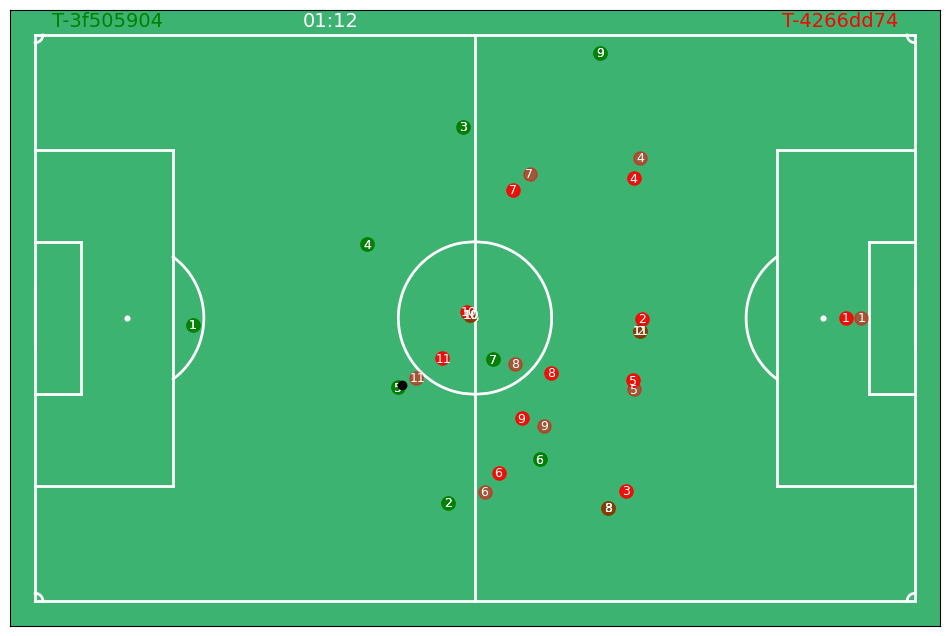

In [5]:
from databallpy.visualize import diff_frames

fig, ax = diff_frames(
    game = game,
    frame_1_idx = selected_frame_idx,
    td_2 = pd.DataFrame(result.best_frame).transpose().astype(game.tracking_data.dtypes),
    frame_2_idx = selected_frame_idx,
    team_colors = ["green", "red"],
)
fig, ax

## Conclusion

You now have a complete end-to-end example for frame-level tactical optimization with simulated annealing:

- loading and preparing tracking data,
- defining objective terms and constraints,
- running the optimizer,
- and comparing baseline vs optimized outcomes visually.

You can extend this setup by tuning objective weights, changing constraints, or plugging in additional optimization algorithms exposed by the optimization module.